In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random 
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from keras.datasets import mnist
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.datasets import mnist


In [3]:
from tensorflow.keras.datasets import mnist
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X_one = train_X
test_X_one = test_X
train_y_one = train_y
test_y_one = test_y

In [4]:
train_y_one.shape
test_y_one.shape

(10000,)

In [5]:
print(train_X.shape)
print(train_y.shape)
print(test_X.shape)
print(test_y.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [6]:
# Creating a small list so we can index onto our training labels 
class_names = ["Zero", "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine"]
len(class_names) 


10

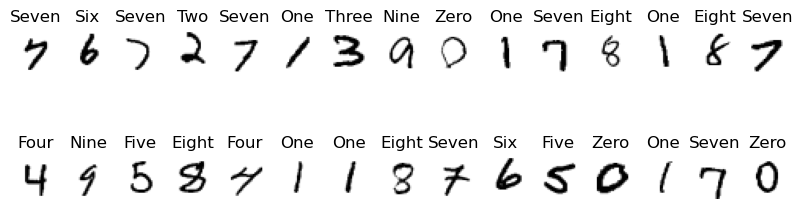

In [7]:
plt.figure(figsize=(10, 3))
for i in range(30):
    ax = plt.subplot(2, 15, i + 1)
    rand_index = random.choice(range(len(train_X)))
    # Reshape the image back to 2D array
    image = train_X[rand_index].reshape(28, 28)
    plt.imshow(image, cmap=plt.cm.binary)
    # Display the class name or label
    plt.title(class_names[train_y[rand_index]]) 
    plt.axis('off')  # Correct method to turn off the axis
    
    
    


In [8]:
import tensorflow as tf
train_y = tf.keras.utils.to_categorical(train_y, 10)/255.0
test_y =  tf.keras.utils.to_categorical(test_y, 10)/255.0

train_X = train_X.reshape((train_X.shape[0], -1))
test_X = test_X.reshape((test_X.shape[0], -1))


In [9]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from keras.datasets import mnist

# Load MNIST data
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# Preprocess the data: Flatten the images and scale the data
train_X = train_X.reshape(train_X.shape[0], -1)
test_X = test_X.reshape(test_X.shape[0], -1)

# Initialize a StandardScaler
scaler = StandardScaler()
# Fit and transform the training data
train_X_scaled = scaler.fit_transform(train_X)
# Transform the testing data using the same scaler
test_X_scaled = scaler.transform(test_X)

# Apply PCA
pca = PCA(n_components=0.95)  # keep 95% of variance
train_X_pca = pca.fit_transform(train_X_scaled)
test_X_pca = pca.transform(test_X_scaled)

# Train a classifier using a Decision Tree
clf = DecisionTreeClassifier()  # You can customize parameters like max_depth if needed
clf.fit(train_X_pca, train_y)

# Evaluate the classifier
predictions = clf.predict(test_X_pca)
accuracy = accuracy_score(test_y, predictions)

print("Accuracy:", accuracy*100)


Accuracy: 82.58


In [10]:
from tensorflow.keras.utils import to_categorical

train_X_one = train_X.reshape((train_X_one.shape[0],28,28,1))
test_X_one = test_X.reshape((test_X_one.shape[0], 28,28,1))

tr_y_one_hot = to_categorical(train_y_one)
ts_y_one_hot = to_categorical(test_y_one)

In [11]:
test_X_one.shape

(10000, 28, 28, 1)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the model
CNN = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

CNN.summary()

CNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
outcomes = CNN.fit(train_X_one, tr_y_one_hot, epochs=10, validation_split=0.1)
losses, accuracy = CNN.evaluate(test_X_one, ts_y_one_hot)
print(" accuracy :", accuracy)




Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 29ms/step - accuracy: 0.7347 - loss: 2.2923 - val_accuracy: 0.9795 - val_loss: 0.0674
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9522 - loss: 0.1650 - val_accuracy: 0.9858 - val_loss: 0.0509
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 87s 33ms/step - accuracy: 0.9670 - loss: 0.1151 - val_accuracy: 0.9867 - val_loss: 0.0628
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9709 - loss: 0.1081 - val_accuracy: 0.9875 - val_loss: 0.0502
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9747 - loss: 0.0855 - val_accuracy: 0.9872 - val_loss: 0.0596
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9773 - loss: 0.0757 - val_accuracy: 0.9858 - val_loss: 0.0609
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9802 - loss: 0.0691 - val_accuracy: 0.9887 - val_loss: 0.0521
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - accuracy: 0.9822 -

In [19]:
import matplotlib as plt
# Plotting the training and validation accuracy
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(outcomes.outcomes['accuracy'], label='Training Accuracy')
plt.plot(outcomes.outcomes['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

# Plotting the training and validation loss
plt.subplot(2, 1, 2)
plt.plot(outcomes.outcomes['loss'], label='Training Loss')
plt.plot(outcomes.outcomes['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,max(plt.ylim())])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

TypeError: 'module' object is not callable

In [37]:
# Define the model
CNN_1 = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='sigmoid', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='sigmoid'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='sigmoid'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

CNN_1.summary()

CNN_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
outcomes = CNN_1.fit(train_X_one, tr_y_one_hot, epochs=10, validation_split=0.1)
losses, accuracy = CNN_1.evaluate(test_X_one, ts_y_one_hot)
print(" accuracy :", accuracy)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.6665 - loss: 0.9947 - val_accuracy: 0.9750 - val_loss: 0.0889
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9660 - loss: 0.1200 - val_accuracy: 0.9847 - val_loss: 0.0527
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9765 - loss: 0.0821 - val_accuracy: 0.9867 - val_loss: 0.0414
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9807 - loss: 0.0648 - val_accuracy: 0.9885 - val_loss: 0.0388
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9837 - loss: 0.0552 - val_accuracy: 0.9870 - val_loss: 0.0423
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9850 - loss: 0.0490 - val_accuracy: 0.9900 - val_loss: 0.0363
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9880 - loss: 0.0404 - val_accuracy: 0.9893 - val_loss: 0.0372
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9881 -

In [38]:
# Define the model
CNN_2 = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='tanh', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='tanh'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='tanh'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

CNN_2.summary()

CNN_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
outcomes = CNN_2.fit(train_X_one, tr_y_one_hot, epochs=10, validation_split=0.1)
losses, accuracy = CNN_2.evaluate(test_X_one, ts_y_one_hot)
print(" accuracy :", accuracy)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8959 - loss: 0.3219 - val_accuracy: 0.9825 - val_loss: 0.0610
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9733 - loss: 0.0893 - val_accuracy: 0.9867 - val_loss: 0.0486
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9750 - loss: 0.0809 - val_accuracy: 0.9862 - val_loss: 0.0504
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9766 - loss: 0.0745 - val_accuracy: 0.9860 - val_loss: 0.0448
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9781 - loss: 0.0698 - val_accuracy: 0.9867 - val_loss: 0.0460
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9800 - loss: 0.0666 - val_accuracy: 0.9877 - val_loss: 0.0475
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9817 - loss: 0.0564 - val_accuracy: 0.9885 - val_loss: 0.0443
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9798 -

In [39]:
from sklearn.model_selection import KFold

k = 5

cross = KFold(n_splits=k, shuffle=True)


for train_index, val_index in cross.split(train_X_one):
    CNN = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
    ])

    CNN.summary()

    CNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    outcomes = CNN.fit(train_X_one, tr_y_one_hot, epochs=10, validation_split=0.1)
    losses, accuracy = CNN.evaluate(test_X_one, ts_y_one_hot)
    print(" accuracy :", accuracy)



Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.7589 - loss: 1.6147 - val_accuracy: 0.9765 - val_loss: 0.0775
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9554 - loss: 0.1546 - val_accuracy: 0.9788 - val_loss: 0.0730
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9678 - loss: 0.1129 - val_accuracy: 0.9832 - val_loss: 0.0576
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9741 - loss: 0.0934 - val_accuracy: 0.9865 - val_loss: 0.0569
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9749 - loss: 0.0889 - val_accuracy: 0.9878 - val_loss: 0.0542
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9795 - loss: 0.0730 - val_accuracy: 0.9840 - val_loss: 0.0557
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9808 - loss: 0.0689 - val_accuracy: 0.9845 - val_loss: 0.0622
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9827 -

C:\Users\nisch\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\nisch\anaconda3\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
